# 04 — LR vs NepBERTa Head-to-Head Comparison

This notebook loads both trained models and pits them against each other on:
1. **The held-out test set** — full metrics, confusion matrices, timing, memory.
2. **A single raw Nepali sentence you type in** — both models' predicted label
   + confidence + inference time, printed side-by-side.

Everything runs from the saved artifacts:

```
outputs/models/
├── tfidf_vectorizer.pkl           ← from notebook 02
├── logistic_regression.pkl        ← from notebook 02
└── nepberta_finetuned/            ← from run_nepberta_local.py
```

No training happens here. If a model is missing, re-run the relevant phase
notebook / script and come back.

In [1]:
# Auto-reload edits in src/ without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
# ============================================================================
# IMPORTS + PATH FIX
# ============================================================================
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import torch

from src import config
from src import feature_extraction as fe
from src import evaluation as ev
from src import visualizations as viz
from src.models import traditional_ml as lr
from src.models import nepberta as nb

# Decide which device NepBERTa runs on. MPS on Apple Silicon, CUDA elsewhere,
# CPU as fallback.
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'NepBERTa will run on: {DEVICE}')

NepBERTa will run on: mps


## Load both trained models ONCE

Loading happens at module boundaries, not per-prediction. The subsequent
comparison cells reuse these objects.

In [3]:
# --- Logistic Regression pipeline ---------------------------------------
# LR inference needs TWO artifacts: the fitted vectorizer (vocab + IDF) and
# the trained classifier. Both live in outputs/models/ from Phase 2.
tfidf_vec = fe.load_vectorizer()          # reads config.TFIDF_VECTORIZER_PATH
lr_model  = lr.load_model()               # reads config.LR_MODEL_PATH
print(f'LR vocabulary size: {len(tfidf_vec.vocabulary_):,}')

# --- NepBERTa ------------------------------------------------------------
# NepBERTa inference needs the fine-tuned model + the matching tokenizer.
# Both are saved as a directory by nb.save_model().
nb_tokenizer, nb_model = nb.load_model()
nb_model = nb_model.to(DEVICE)
nb_model.eval()                            # disable dropout for inference
print(f'NepBERTa parameters: {sum(p.numel() for p in nb_model.parameters()):,}')

LR vocabulary size: 10,000
NepBERTa parameters: 109,484,547


## Cell A — Full test-set evaluation, both models side-by-side

Runs `predict` on the same `test.csv` for each model, computes every metric
we care about via our shared `evaluation` module, and prints them in one
clean table. Also plots the two confusion matrices next to each other so
you can eyeball WHERE each model makes its mistakes (e.g., "does NepBERTa
confuse Positive with Neutral as often as LR does?").

In [ ]:
# Load the held-out test set (produced by src.preprocessing).
import os
test = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'test.csv'))
print(f'Test set: {test.shape}\n')

# ---- LR ------------------------------------------------------------------
print('Evaluating Logistic Regression...')
X_test = fe.transform(tfidf_vec, test['text'])
with ev.Profiler() as lr_prof:
    lr_pred = lr.predict(lr_model, X_test)
lr_metrics = ev.compute_performance_metrics(test['label'], lr_pred)
print(f'  {lr_prof.elapsed_seconds*1000:.1f} ms total, '
      f'{lr_prof.elapsed_seconds*1000/len(lr_pred):.4f} ms/sample')

# ---- NepBERTa ------------------------------------------------------------
print('\nEvaluating NepBERTa...')
with ev.Profiler() as nb_prof:
    nb_pred = nb.predict(nb_model, nb_tokenizer, test['text'])
nb_metrics = ev.compute_performance_metrics(test['label'], nb_pred)
print(f'  {nb_prof.elapsed_seconds:.1f} s total, '
      f'{nb_prof.elapsed_seconds*1000/len(nb_pred):.2f} ms/sample')

# ---- Side-by-side summary table -----------------------------------------
summary = pd.DataFrame({
    'Logistic Regression': ev.flatten_metrics(lr_metrics),
    'NepBERTa':            ev.flatten_metrics(nb_metrics),
})
# Add the efficiency rows.
summary.loc['inference_ms_per_sample'] = [
    lr_prof.elapsed_seconds * 1000 / len(lr_pred),
    nb_prof.elapsed_seconds * 1000 / len(nb_pred),
]
summary.loc['peak_memory_mb'] = [lr_prof.peak_memory_mb, nb_prof.peak_memory_mb]

# Higher-is-better vs lower-is-better classification, used for both the
# in-notebook highlight AND the persisted CSV's `winner` column.
HIGHER_IS_BETTER = {
    'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1',
    'precision_Negative', 'precision_Neutral', 'precision_Positive',
    'recall_Negative', 'recall_Neutral', 'recall_Positive',
    'f1_Negative', 'f1_Neutral', 'f1_Positive',
}
LOWER_IS_BETTER = {'inference_ms_per_sample', 'peak_memory_mb'}

def _winner_for(row):
    """Return the column name that wins this metric, or '' for support rows."""
    if row.name in HIGHER_IS_BETTER:
        return row.idxmax()
    if row.name in LOWER_IS_BETTER:
        return row.idxmin()
    return ''

# ---- Persist a clean comparison_summary.csv -----------------------------
# Plain-CSV version with one extra `winner` column. The notebook keeps its
# styled HTML view below; this file is the durable artifact downstream code
# (and any future reports) can read.
summary_to_save = summary.copy()
summary_to_save['winner'] = summary_to_save.apply(_winner_for, axis=1)
csv_path = os.path.join(config.RESULTS, 'comparison_summary.csv')
os.makedirs(config.RESULTS, exist_ok=True)
summary_to_save.to_csv(csv_path, index_label='metric')
print(f'\nSaved comparison summary → {csv_path}')

# ---- Notebook display: styled table with green-highlighted winners ------
def highlight(row):
    styles = ['', '']
    if row.name in HIGHER_IS_BETTER:
        winner = 0 if row.iloc[0] > row.iloc[1] else 1
    elif row.name in LOWER_IS_BETTER:
        winner = 0 if row.iloc[0] < row.iloc[1] else 1
    else:
        return styles  # support rows, etc.
    styles[winner] = 'background-color: #e8f5e9; font-weight: bold;'
    return styles

summary.style.apply(highlight, axis=1).format('{:.4f}', subset=pd.IndexSlice[:, :])

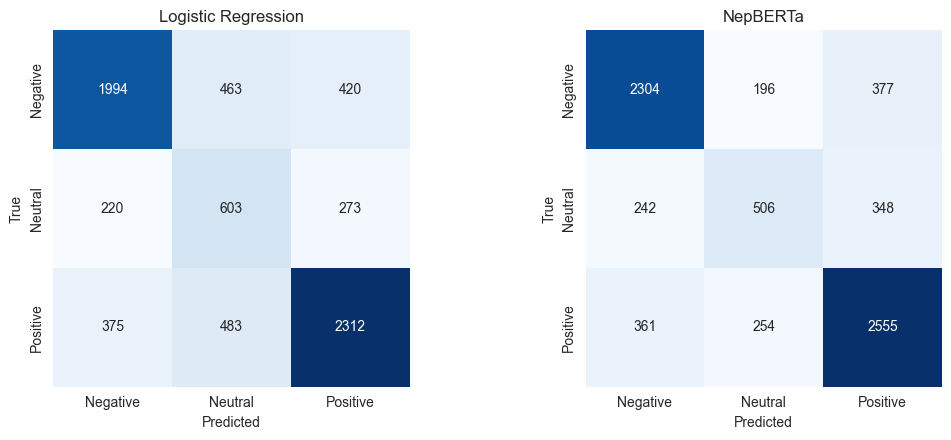

In [5]:
# ---- Confusion matrices side-by-side ------------------------------------
# Same metric function, same labels → the two heatmaps are directly comparable.
# Look for: does NepBERTa fix LR's weakest spot (Neutral class) or make it worse?
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metrics, title in [
    (ax1, lr_metrics, 'Logistic Regression'),
    (ax2, nb_metrics, 'NepBERTa'),
]:
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=config.LABEL_NAMES, yticklabels=config.LABEL_NAMES,
                cbar=False, ax=ax, square=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f'{config.FIGURES}/confusion_matrix_side_by_side.png', dpi=config.FIGURE_DPI,
            bbox_inches='tight')
plt.show()

## Cell B — Type a raw sentence and compare both models

Change the string below and re-run this cell. You'll see:
- Each model's predicted label + its confidence (softmax probability)
- Wall-clock inference time (ms) for that single input
- The full per-class probability breakdown

For a NepBERTa-only single-input demo, use `notebooks/05_demo_prototype.ipynb`.

In [10]:
# ============================================================================
# EDIT THIS LINE — then re-run the cell
# ============================================================================
sample_text = 'ठिक छ'


# ---- LR single-sentence prediction --------------------------------------
lr_t0 = time.perf_counter()
lr_vec     = fe.transform(tfidf_vec, [sample_text])
lr_pred_id = lr.predict(lr_model, lr_vec)[0]
lr_probs   = lr.predict_proba(lr_model, lr_vec)[0]
lr_ms      = (time.perf_counter() - lr_t0) * 1000

# ---- NepBERTa single-sentence prediction --------------------------------
nb_t0 = time.perf_counter()
nb_pred_id = nb.predict(nb_model, nb_tokenizer, [sample_text])[0]
nb_probs   = nb.predict_proba(nb_model, nb_tokenizer, [sample_text])[0]
nb_ms      = (time.perf_counter() - nb_t0) * 1000

# ---- Display ------------------------------------------------------------
print(f'Input: {sample_text}\n')

comparison = pd.DataFrame({
    'Logistic Regression': {
        'predicted_label':           config.LABEL_NAMES[lr_pred_id],
        'confidence':                f'{lr_probs[lr_pred_id]:.2%}',
        'inference_ms':              f'{lr_ms:.2f}',
        f'prob_{config.LABEL_NAMES[0]}': f'{lr_probs[0]:.3f}',
        f'prob_{config.LABEL_NAMES[1]}': f'{lr_probs[1]:.3f}',
        f'prob_{config.LABEL_NAMES[2]}': f'{lr_probs[2]:.3f}',
    },
    'NepBERTa': {
        'predicted_label':           config.LABEL_NAMES[nb_pred_id],
        'confidence':                f'{nb_probs[nb_pred_id]:.2%}',
        'inference_ms':              f'{nb_ms:.2f}',
        f'prob_{config.LABEL_NAMES[0]}': f'{nb_probs[0]:.3f}',
        f'prob_{config.LABEL_NAMES[1]}': f'{nb_probs[1]:.3f}',
        f'prob_{config.LABEL_NAMES[2]}': f'{nb_probs[2]:.3f}',
    },
})

# Flag agreement / disagreement at the top for quick scan.
if lr_pred_id == nb_pred_id:
    print(f'Both models AGREE: {config.LABEL_NAMES[lr_pred_id]}\n')
else:
    print(f'Models DISAGREE — LR says {config.LABEL_NAMES[lr_pred_id]}, '
          f'NepBERTa says {config.LABEL_NAMES[nb_pred_id]}\n')

comparison

Input: ठिक छ

Models DISAGREE — LR says Negative, NepBERTa says Positive



,Logistic Regression,NepBERTa
predicted_label,Negative,Positive
confidence,49.79%,94.28%
inference_ms,1.66,364.42
prob_Negative,0.498,0.014
prob_Neutral,0.215,0.043
prob_Positive,0.287,0.943


### Try-it-yourself suggestions

Swap in different sentences to probe where the two models diverge:

```python
# Clear positive
sample_text = 'मलाई यो काम एकदमै मन पर्‍यो'

# Clear negative
sample_text = 'सरकार भ्रष्ट छ, देशको अवस्था बिग्रिएको छ'

# Neutral / news-like
sample_text = 'काठमाडौंमा आज पानी पर्‍यो'

# Sarcasm — usually where LR struggles and NepBERTa sometimes helps
sample_text = 'ऊ त साह्रै गज्जबको मान्छे हो, जहिले पनि झूट बोल्छ'

# Short ambiguous — check confidence
sample_text = 'ठिक छ'
```
